In [1]:
# !pip install onnx==1.16.0 onnxruntime==1.16.3 onnxscript
# !pip uninstall -y onnx onnxruntime onnxscript
# https://bitbucket.ap-team.ru/projects/RES/repos/res.models.inference/browse

In [6]:
!pip uninstall -y onnxruntime onnxruntime-gpu
# !pip install onnx==1.16.0 onnxruntime-gpu==1.17.1 onnxscript
# !apt-get install libcudnn8 libcudnn8-dev # маст хев чтобы работало на гпу

Found existing installation: onnxruntime-gpu 1.17.1
Uninstalling onnxruntime-gpu-1.17.1:
  Successfully uninstalled onnxruntime-gpu-1.17.1


In [3]:
# !pip install efficientnet_pytorch

In [4]:
from omegaconf import OmegaConf
from src.model import TransformDecoder, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
from PIL import Image

# config = OmegaConf.load('configs/train_config_vit.yaml')
# model = ImageTransformPredictor(config.model)

# checkpoint_path = 'checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

# checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.to('cpu')
# model.eval()
# print('ready')

In [3]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

In [15]:
preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

#### ImageEncoder

In [154]:
class ImageEncoder(nn.Module):
    def __init__(self, out_token_n_embd: int = 512):
        super().__init__()
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.vit = vit_b_16(weights=weights)
        self.vit.heads = nn.Identity()
        self.feature_dim = self.vit.hidden_dim
        self.proj = nn.Linear(self.feature_dim, out_token_n_embd)
        self.patch_size = self.vit.conv_proj.kernel_size[0]
        self.hidden_dim = self.vit.hidden_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        x = self.vit.conv_proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        class_token = self.vit.class_token.expand(batch_size, -1, -1)
        x = torch.cat([class_token, x], dim=1)
        x = x + self.vit.encoder.pos_embedding
        x = self.vit.encoder.layers(x)
        if hasattr(self.vit.encoder, 'ln'):
            x = self.vit.encoder.ln(x)
        x = self.proj(x)
        return x

In [155]:
encoder = ImageEncoder()
encoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredoctor/image_encoder.pth'))
encoder.eval()
print('ready')

ready


In [110]:
# import os
# os.environ["TORCH_ONNX_EXPORT_USE_DYNAMO"] = "0"

# import torch

# dummy_input = torch.randn(1, 3, 224, 224, device='cpu')

# torch.onnx.export(
#     encoder,
#     dummy_input,
#     "/mnt/DATA2/dorin/weights/transformpredoctor/image_encoder.onnx",
#     input_names=["image_input"],
#     output_names=["image_embeddings"],
#     opset_version=18,
#     do_constant_folding=True,
#     dynamic_axes={
#         "image_input": {
#             0: "batch_size"
#         },
#         "image_embeddings": {
#             0: "batch_size",
#             1: "num_patches"
#         }
#     },
#     verbose=False,
#     dynamo=False
# )

In [7]:
# !pip install numpy==1.26.4

#### how to use onnx

In [2]:
import onnxruntime as ort

In [3]:
ort.get_available_providers()

['TensorrtExecutionProvider',
 'CUDAExecutionProvider',
 'AzureExecutionProvider',
 'CPUExecutionProvider']

In [4]:
ort.__version__

'1.17.1'

In [19]:
# 1. Указываем провайдеры: сначала GPU (CUDA), потом CPU
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']

# 2. Передаем providers в сессию
ort_session = ort.InferenceSession(
    "/mnt/DATA2/dorin/weights/transformpredoctor/image_encoder.onnx",
    providers=providers
)

# Проверка: какие провайдеры активны
print("Активные провайдеры:", ort_session.get_providers())

Активные провайдеры: ['CUDAExecutionProvider', 'CPUExecutionProvider']


2026-02-24 14:56:47.218842072 [W:onnxruntime:, transformer_memcpy.cc:74 ApplyImpl] 12 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


по хорошему нужно экспортировать модель уже на гпу из торча иначе происходит переброс некоторых операций с цпу на гпу

```
2026-02-24 14:56:47.218842072 [W:onnxruntime:, transformer_memcpy.cc:74 ApplyImpl] 12 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
```

In [23]:
ort_session = ort.InferenceSession("/mnt/DATA2/dorin/weights/transformpredoctor/image_encoder.onnx")

inputs = ort_session.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = ort_session.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: image_input, shape: ['batch_size', 3, 224, 224], type: tensor(float)
Output name: image_embeddings, shape: ['batch_size', 197, 512], type: tensor(float)


In [20]:
dummy_input = torch.randn(1, 3, 224, 224, device='cpu')

In [21]:
import numpy as np
outputs = ort_session.run(None, {'image_input': np.array(dummy_input)})

In [22]:
outputs[0].shape

(1, 197, 512)

In [14]:
dummy_input = torch.randn(1, 3, 224, 224, device='cpu')

In [15]:
# !python -m pip install --force-reinstall -U ap_res_models_inference --index-url https://nexus.ap-team.ru/repository/pypi/simple

from ap_res_models_inference import get_model
import numpy as np

model = get_model(
    engine_name= 'onnx',
    path_to_weights='/mnt/DATA2/dorin/weights/transformpredoctor/image_encoder.onnx',
    use_gpu=0
)

outputs = model(image_input=np.array(dummy_input)) # image_input нейминг как при экспорте
outputs.shape

(1, 197, 512)

In [16]:
onnx_model = model.model
onnx_model.get_providers()

['CPUExecutionProvider']

#### decoder and fuser

In [4]:
class ImageFuser(nn.Module):
    def __init__(self, embed_dim: int = 512):
        super().__init__()
        self.embed_dim = embed_dim
        self.sep_token = nn.Parameter(torch.randn(1, 1, embed_dim))

    def forward(self, embs1: torch.Tensor, embs2: torch.Tensor) -> torch.Tensor:
        B = embs1.shape[0]
        sep = self.sep_token.expand(B, -1, -1)
        return torch.cat([embs1, sep, embs2], dim=1)


# =============================================================================
# DecoderBlock:
# =============================================================================

class DecoderBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln_1 = nn.LayerNorm(512, elementwise_affine=False)
        self.ln_2 = nn.LayerNorm(512, elementwise_affine=False)
        self.ln_3 = nn.LayerNorm(512, elementwise_affine=False)

        self.attn = nn.MultiheadAttention(
            embed_dim=512,
            num_heads=8,
            dropout=0.1,
            bias=False,
            batch_first=True,
        )

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=512,
            num_heads=8,
            dropout=0.1,
            bias=False,
            batch_first=True,
        )

        self.net = nn.Sequential(
            nn.Linear(512, 2048, bias=False),
            nn.GELU(),
            nn.Linear(2048, 512, bias=False),
        )
        self.dropout_layer = nn.Dropout(0.1)

        mask = torch.triu(torch.full((15, 15), float('-inf')), diagonal=1)
        self.register_buffer("future_mask", mask, persistent=False)

    def forward(self, x: torch.Tensor, images_embeddings: torch.Tensor) -> torch.Tensor:
        _, T, _ = x.shape
        attn_mask = self.future_mask[:T, :T].to(x.device)
        x = x + self.attn(
            query=self.ln_1(x),
            key=self.ln_1(x),
            value=self.ln_1(x),
            attn_mask=attn_mask,
            need_weights=False
        )[0]

        x = x + self.cross_attn(
            query=self.ln_2(x),
            key=images_embeddings,
            value=images_embeddings,
            need_weights=False
        )[0]

        x = x + self.dropout_layer(self.net(self.ln_3(x)))
        return x


# =============================================================================
# TransformationDecoder
# =============================================================================

class TransformationDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.n_embd = 512
        self.n_head = 8
        self.n_layer = 3
        self.max_seq_len = 15
        self.vocab_size = 14
        self.dropout = 0.1
        self.bias = False
        self.bos_token_id = 1
        self.eos_token_id = 2
        self.pad_token_id = 0

        self.token_embedding = nn.Embedding(self.vocab_size, self.n_embd)
        self.position_embedding = nn.Embedding(self.max_seq_len, self.n_embd)
        self.blocks = nn.ModuleList([DecoderBlock() for _ in range(self.n_layer)])
        self.ln_f = nn.LayerNorm(self.n_embd, elementwise_affine=self.bias)
        self.lm_head = nn.Linear(self.n_embd, self.vocab_size, bias=False)

    def forward(self, images_embeddings: torch.Tensor, idx: torch.Tensor) -> torch.Tensor:
        _, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)
        x = tok_emb + pos_emb

        for block in self.blocks:
            x = block(x, images_embeddings)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits[:, -1, :]

    @torch.no_grad()
    def generate(
        self,
        images_embeddings: torch.Tensor,
        max_new_tokens: int = 10,
        temperature: float = 1.0,
        do_sample: bool = False,
    ) -> torch.Tensor:
        B = images_embeddings.shape[0]
        device = images_embeddings.device
        total_len = 1 + max_new_tokens
        assert total_len <= self.max_seq_len

        idx = torch.full((B, 1), self.bos_token_id, dtype=torch.long, device=device)
        finished = torch.zeros(B, dtype=torch.bool, device=device)

        for _ in range(max_new_tokens):
            logits = self(images_embeddings, idx)
            next_logits = logits / temperature
            next_logits[:, self.pad_token_id] = -float('inf')
            next_logits[:, self.bos_token_id] = -float('inf')

            if do_sample:
                probs = F.softmax(next_logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1).squeeze(-1)
            else:
                idx_next = torch.argmax(next_logits, dim=-1)

            newly_finished = (idx_next == self.eos_token_id)
            finished = finished | newly_finished
            idx = torch.cat([idx, idx_next.unsqueeze(-1)], dim=1)

            if finished.all():
                break

        if idx.size(1) < total_len:
            pad = torch.full(
                (B, total_len - idx.size(1)),
                self.pad_token_id,
                device=device,
                dtype=torch.long
            )
            idx = torch.cat([idx, pad], dim=1)
        else:
            idx = idx[:, :total_len]

        for i in range(B):
            eos_pos = (idx[i] == self.eos_token_id).nonzero(as_tuple=True)[0]
            if eos_pos.numel() > 0:
                idx[i, eos_pos[0].item() + 1:] = self.pad_token_id

        return idx

In [5]:
fuser = ImageFuser()
fuser.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredoctor/fuser.pth'))
fuser.eval()
print('ready')

ready


In [7]:
# dummy_source = torch.randn(1, 32, 512, device='cpu')
# dummy_query = torch.randn(1, 32, 512, device='cpu')

# torch.onnx.export(
#         fuser,
#         (dummy_source, dummy_query),
#         '/mnt/DATA2/dorin/weights/transformpredoctor/fuser.onnx',
#         input_names=["source_embeddings", "query_embeddings"],
#         output_names=["fused_context"],
#         opset_version=18,
#         do_constant_folding=True,
#         dynamic_axes={
#             "source_embeddings": {0: "batch_size", 1: "source_seq_len"},
#             "query_embeddings": {0: "batch_size", 1: "query_seq_len"},
#             "fused_context": {0: "batch_size", 1: "fused_seq_len"}
#         },
#         dynamo=False,
#         verbose=False
#     )

In [17]:
decoder = TransformationDecoder()
decoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredoctor/decoder.pth'))
decoder.eval()
print('ready')

ready


In [18]:
# import os
# os.environ["TORCH_ONNX_EXPORT_USE_DYNAMO"] = "0"

# dummy_context = torch.randn(
#     1,
#     65,
#     512,
#     device='cpu',
#     dtype=torch.float32,
#     requires_grad=False
# )

# dummy_tokens = torch.full(
#     (1, 1),
#     fill_value=1,  # bos_token_id
#     device='cpu',
#     dtype=torch.long  # критично: Embedding ожидает int64
# )

# torch.onnx.export(
#     decoder,
#     (dummy_context, dummy_tokens),  # context: [B, L, D], tokens: [B, T]
#     "decoder_step.onnx",
#     input_names=["context_embeddings", "token_ids"],
#     output_names=["next_logits"],
#     opset_version=18,
#     do_constant_folding=True,
#     dynamic_axes={
#         "context_embeddings": {0: "batch_size", 1: "context_len"},
#         "token_ids": {0: "batch_size", 1: "seq_len"},
#         "next_logits": {0: "batch_size"}
#     },
#     dynamo=False,
#     verbose=False
# )

/tmp/ipykernel_650128/2048956586.py:20: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


['rotate_270', 'crop']


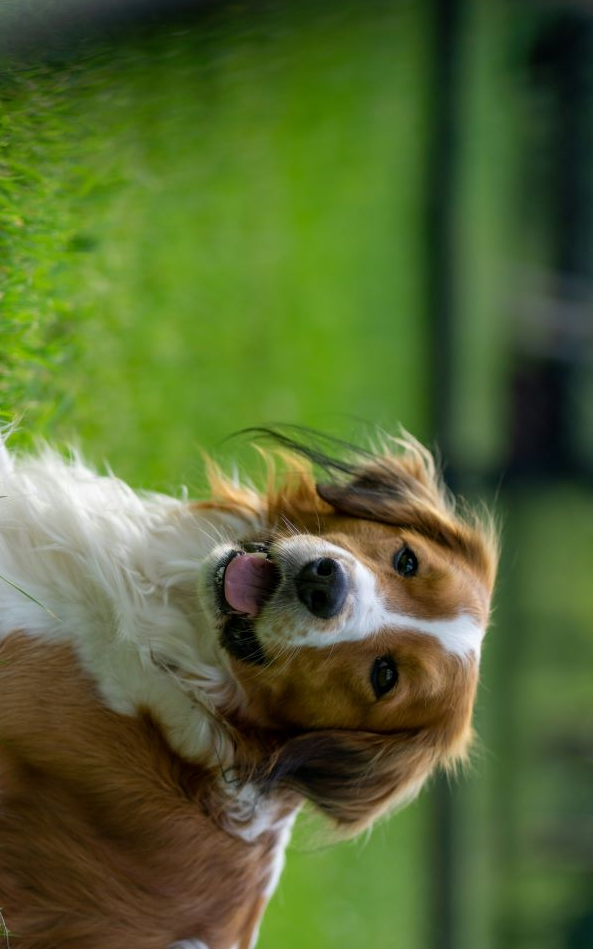

In [171]:
image_path = 'assets/image.jpg'
image = Image.open(image_path)

it = ImageTransformer()
transformed_image, sequence = it.transform(image, p=0.3)
print(sequence)
transformed_image

In [172]:
image_tensor = preprocess(image).unsqueeze(0).repeat(3, 1, 1, 1)
transformed_image_tensor = preprocess(transformed_image).unsqueeze(0).repeat(3, 1, 1, 1)

In [173]:
tokenizer = TransformTokenizer()

In [174]:
image_embs, transformed_image_embs = encoder(image_tensor), encoder(transformed_image_tensor)

In [175]:
image_embs.shape

torch.Size([3, 197, 512])

In [176]:
images_embeddings = fuser(image_embs, transformed_image_embs)

In [181]:
generated = decoder.generate(images_embeddings, max_new_tokens=10, do_sample=False) #, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence}")

Predicted: ['rotate_270', 'crop']
Target: ['rotate_270', 'crop']


In [182]:
generated

tensor([[ 1,  7, 10,  2,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  7, 10,  2,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  7, 10,  2,  0,  0,  0,  0,  0,  0,  0]])

#### Onnx pipeline

In [8]:
import onnxruntime as ort
import numpy as np
import torch
from PIL import Image
import torchvision.transforms as T

In [9]:
model_dir = "/mnt/DATA2/dorin/weights/transformpredoctor"

encoder_sess = ort.InferenceSession(
    f"{model_dir}/image_encoder_qformer.onnx",
    providers=["CPUExecutionProvider"]
)
fuser_sess = ort.InferenceSession(
    f"{model_dir}/fuser.onnx",
    providers=["CPUExecutionProvider"]
)
decoder_sess = ort.InferenceSession(
    f"{model_dir}/decoder_step.onnx",
    providers=["CPUExecutionProvider"]
)

In [10]:
inputs = encoder_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = encoder_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: image_input, shape: ['batch_size', 3, 224, 224], type: tensor(float)
Output name: image_embeddings, shape: ['batch_size', 'num_patches', 'Addimage_embeddings_dim_2'], type: tensor(float)


In [11]:
inputs = fuser_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = fuser_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: source_embeddings, shape: ['batch_size', 'source_seq_len', 512], type: tensor(float)
Input name: query_embeddings, shape: ['batch_size', 'query_seq_len', 512], type: tensor(float)
Output name: fused_context, shape: ['batch_size', 'fused_seq_len', 512], type: tensor(float)


In [12]:
inputs = decoder_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = decoder_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: context_embeddings, shape: ['batch_size', 'context_len', 512], type: tensor(float)
Input name: token_ids, shape: ['batch_size', 'seq_len'], type: tensor(int64)
Output name: next_logits, shape: ['batch_size', 14], type: tensor(float)


In [13]:
# Параметры
VOCAB_SIZE = 14
BOS_TOKEN_ID = 1
EOS_TOKEN_ID = 2
PAD_TOKEN_ID = 0
MAX_NEW_TOKENS = 10

# Препроцессинг изображений
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =============================================================================
# 2. Загрузка и кодирование изображений
# =============================================================================

image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1).convert("RGB")
# image_2 = Image.open(image_path_2).convert("RGB")
it = ImageTransformer()
image_2, target = it.transform(image_1, p=0.3)

print(f"Image 1: {image_1.size}")
print(f"Image 2: {image_2.size}")

# Энкодинг
input_1 = transform(image_1).unsqueeze(0).numpy().astype(np.float32)
input_2 = transform(image_2).unsqueeze(0).numpy().astype(np.float32)

embs_1 = encoder_sess.run(None, {"image_input": input_1})[0]  # [1, 197, 512]
embs_2 = encoder_sess.run(None, {"image_input": input_2})[0]  # [1, 197, 512]

print(f"Embeddings 1: {embs_1.shape}")
print(f"Embeddings 2: {embs_2.shape}")

# =============================================================================
# 3. Fusion эмбеддингов
# =============================================================================

fused_context = fuser_sess.run(None, {
    "source_embeddings": embs_1.astype(np.float32),
    "query_embeddings": embs_2.astype(np.float32)
})[0]  # [1, 395, 512]

print(f"Fused context: {fused_context.shape}")

# =============================================================================
# 4. Генерация последовательности (decoder loop)
# =============================================================================

idx = np.full((1, 1), BOS_TOKEN_ID, dtype=np.int64)
finished = np.zeros(1, dtype=bool)

for step in range(MAX_NEW_TOKENS):
    logits = decoder_sess.run(None, {
        "context_embeddings": fused_context.astype(np.float32),
        "token_ids": idx
    })[0]  # [1, vocab_size]
    
    # Mask special tokens
    logits[:, [PAD_TOKEN_ID, BOS_TOKEN_ID]] = -float('inf')
    
    # Greedy decoding
    next_token = np.argmax(logits, axis=-1).astype(np.int64)
    
    # Check EOS
    newly_finished = (next_token == EOS_TOKEN_ID)
    finished = finished | newly_finished
    idx = np.concatenate([idx, next_token[:, None]], axis=1)
    
    if finished.all():
        break

# Pad to fixed length
total_len = 1 + MAX_NEW_TOKENS
if idx.shape[1] < total_len:
    pad = np.full((1, total_len - idx.shape[1]), PAD_TOKEN_ID, dtype=np.int64)
    idx = np.concatenate([idx, pad], axis=1)

# Truncate after first EOS
eos_pos = np.where(idx[0] == EOS_TOKEN_ID)[0]
if len(eos_pos) > 0:
    idx[0, eos_pos[0] + 1:] = PAD_TOKEN_ID

print(f"Generated tokens: {idx[0]}")

# =============================================================================
# 5. Декодинг через ваш токенайзер
# =============================================================================

# Конвертируем в torch tensor для совместимости с вашим токенайзером
generated = torch.from_numpy(idx)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)

print(f"\n=== Result ===")
print(f"Predicted: {tokens}")
print(f"Target: {target}")

NameError: name 'ImageTransformer' is not defined

In [14]:
VOCAB_SIZE = 14
BOS_TOKEN_ID = 1
EOS_TOKEN_ID = 2
PAD_TOKEN_ID = 0
MAX_NEW_TOKENS = 10

# Препроцессинг изображений
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =============================================================================
# 1. Инициализация ONNX сессий
# =============================================================================

model_dir = "/mnt/DATA2/dorin/weights/transformpredoctor"

encoder_sess = __import__('onnxruntime').InferenceSession(
    f"{model_dir}/image_encoder.onnx",
    providers=["CPUExecutionProvider"]
)
fuser_sess = __import__('onnxruntime').InferenceSession(
    f"{model_dir}/fuser.onnx",
    providers=["CPUExecutionProvider"]
)
decoder_sess = __import__('onnxruntime').InferenceSession(
    f"{model_dir}/decoder_step.onnx",
    providers=["CPUExecutionProvider"]
)

# =============================================================================
# 2. Загрузка и кодирование изображений
# =============================================================================

image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1).convert("RGB")
# image_2 = Image.open(image_path_2).convert("RGB")
it = ImageTransformer()
image_2, target = it.transform(image_1, p=0.3)

print(f"Image 1: {image_1.size}")
print(f"Image 2: {image_2.size}")

# Энкодинг
input_1 = transform(image_1).unsqueeze(0).numpy().astype(np.float32)
input_2 = transform(image_2).unsqueeze(0).numpy().astype(np.float32)

embs_1 = encoder_sess.run(None, {"image_input": input_1})[0]  # [B, 197, 512]
embs_2 = encoder_sess.run(None, {"image_input": input_2})[0]  # [B, 197, 512]

# embs_1 = np.concatenate([embs_1, embs_1, embs_1], axis=0)  # [3, 197, 512]
# embs_2 = np.concatenate([embs_2, embs_2, embs_2], axis=0)  # [3, 197, 512]

print(f"Embeddings 1: {embs_1.shape}")
print(f"Embeddings 2: {embs_2.shape}")

# =============================================================================
# 3. Fusion эмбеддингов
# =============================================================================

fused_context = fuser_sess.run(None, {
    "source_embeddings": embs_1.astype(np.float32),
    "query_embeddings": embs_2.astype(np.float32)
})[0]  # [B, 395, 512]

print(f"Fused context: {fused_context.shape}")

# =============================================================================
# 4. Генерация последовательности (decoder loop) - ИСПРАВЛЕНО ДЛЯ БАТЧЕЙ
# =============================================================================

B = fused_context.shape[0]  # ← Получаем реальный размер батча

idx = np.full((B, 1), BOS_TOKEN_ID, dtype=np.int64)  # [B, 1]
finished = np.zeros(B, dtype=bool)                   # [B]

for step in range(MAX_NEW_TOKENS):
    logits = decoder_sess.run(None, {
        "context_embeddings": fused_context.astype(np.float32),
        "token_ids": idx
    })[0]  # [B, vocab_size]
    
    # Mask special tokens
    logits[:, [PAD_TOKEN_ID, BOS_TOKEN_ID]] = -float('inf')
    
    # Greedy decoding
    next_token = np.argmax(logits, axis=-1).astype(np.int64)  # [B]
    
    # Check EOS
    newly_finished = (next_token == EOS_TOKEN_ID)
    finished = finished | newly_finished
    idx = np.concatenate([idx, next_token[:, None]], axis=1)  # [B, step+2]
    
    if finished.all():
        break

# Pad to fixed length - ИСПРАВЛЕНО: используем B вместо 1
total_len = 1 + MAX_NEW_TOKENS
if idx.shape[1] < total_len:
    pad = np.full((B, total_len - idx.shape[1]), PAD_TOKEN_ID, dtype=np.int64)  # [B, remaining]
    idx = np.concatenate([idx, pad], axis=1)

# Truncate after first EOS - ИСПРАВЛЕНО: цикл по всем элементам батча
for i in range(B):
    eos_pos = np.where(idx[i] == EOS_TOKEN_ID)[0]
    if len(eos_pos) > 0:
        idx[i, eos_pos[0] + 1:] = PAD_TOKEN_ID

print(f"Generated tokens: {idx}")
print(f"Shape: {idx.shape}")

# =============================================================================
# 5. Декодинг через ваш токенайзер
# =============================================================================

# Конвертируем в torch tensor для совместимости с вашим токенайзером
generated = torch.from_numpy(idx)

tokenizer = TransformTokenizer()

# Для батча: декодим каждый элемент отдельно
for i in range(B):
    tokens = tokenizer.decode(generated[i], skip_special_tokens=True)
    print(f"\n=== Sample {i} ===")
    print(f"Predicted: {tokens}")
    print(f"Target: {target}")

NameError: name 'ImageTransformer' is not defined

In [75]:
idx = np.full((1, 1), BOS_TOKEN_ID, dtype=np.int64)
# idx = np.repeat(idx, 3, 0)

logits = decoder_sess.run(None, {
    "context_embeddings": fused_context.astype(np.float32),
    "token_ids": idx
})[0]  # [1, vocab_size]

In [70]:
logits_stable = logits - logits.max(axis=-1, keepdims=True)
probs = np.exp(logits_stable) / np.exp(logits_stable).sum(axis=-1, keepdims=True)
similarity_score = 1 - probs[:, EOS_TOKEN_ID]

In [71]:
probs

array([[5.2565942e-12, 2.9645620e-12, 1.0124832e-06, 9.2147856e-10,
        1.7025861e-05, 5.5807239e-01, 4.0370646e-06, 2.9392537e-02,
        1.4658166e-04, 1.1485144e-03, 4.8112537e-04, 3.5411343e-02,
        2.3613254e-02, 3.5171217e-01],
       [5.2565942e-12, 2.9645620e-12, 1.0124832e-06, 9.2147856e-10,
        1.7025861e-05, 5.5807239e-01, 4.0370646e-06, 2.9392537e-02,
        1.4658166e-04, 1.1485144e-03, 4.8112537e-04, 3.5411343e-02,
        2.3613254e-02, 3.5171217e-01],
       [5.2565942e-12, 2.9645620e-12, 1.0124832e-06, 9.2147856e-10,
        1.7025861e-05, 5.5807239e-01, 4.0370646e-06, 2.9392537e-02,
        1.4658166e-04, 1.1485144e-03, 4.8112537e-04, 3.5411343e-02,
        2.3613254e-02, 3.5171217e-01]], dtype=float32)

In [72]:
similarity_score

array([0.999999, 0.999999, 0.999999], dtype=float32)